In [ ]:
!pip install -q -U torch torchvision transformers peft bitsandbytes datasets accelerate
!pip install -q flash-attn --no-build-isolation
!pip install -q qwen-vl-utils

from google.colab import drive
from huggingface_hub import login

drive.mount('/content/drive')

login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 147.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.

In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_from_disk
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import io
import ast
import os

model_id = "Qwen/Qwen2-VL-7B-Instruct"

if os.path.exists("/content/temp_dataset_fast"):
    dataset_path = "/content/temp_dataset_fast"
    print("Veri Hızlı Diskten okunacak.")
else:
    dataset_path = "/content/drive/MyDrive/FoodDataset_Qwen_Final"
    print("Veri Drive'dan okunacak (Biraz yavaş olabilir ama çalışır).")

output_dir = "/content/drive/MyDrive/Qwen2-VL-Calorie-Model-Final"

print("Model yükleniyor...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="flash_attention_2",
    torch_dtype=torch.bfloat16
)
base_model = prepare_model_for_kbit_training(base_model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(base_model, peft_config)
processor = AutoProcessor.from_pretrained(model_id, min_pixels=256*28*28, max_pixels=1280*28*28)

print("Veri seti bağlanıyor...")
dataset = load_from_disk(dataset_path)
print(f"Toplam Veri: {len(dataset)}")
print(".map() işlemi İPTAL EDİLDİ. Veriler eğitim anında canlı işlenecek.")

def collate_fn(examples):

    texts = []
    images = []

    for example in examples:
        img_data = example['image']
        try:
            if isinstance(img_data, dict):
                if 'bytes' in img_data and img_data['bytes']:
                    image = Image.open(io.BytesIO(img_data['bytes']))
                elif 'path' in img_data and img_data['path']:
                    image = Image.open(img_data['path'])
                else:
                    image = Image.new('RGB', (224, 224), color='black')
            else:
                image = img_data

            if image.mode != "RGB":
                image = image.convert("RGB")

        except Exception as e:
            print(f"Resim okuma hatası: {e}")
            image = Image.new('RGB', (224, 224), color='black')

        images.append(image)

        ingredients = example.get('ingredients', [])
        if isinstance(ingredients, str):
            try: ingredients = ast.literal_eval(ingredients)
            except: ingredients = []

        response_text = "Yemek Analizi:\n"
        calculated_total = 0

        if ingredients:
            for ing in ingredients:
                name = ing.get('name', 'Bilinmiyor')
                grams = ing.get('grams', 0)
                cals = ing.get('calories', 0)
                response_text += f"- {name} ({grams}g): {cals:.1f} kcal\n"
                calculated_total += cals

        actual_total = example.get('total_calories')
        if actual_total is None:
            actual_total = calculated_total

        response_text += f"\nToplam Tahmini Kalori: {actual_total:.1f} kcal"

        system_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
        user_prompt = "<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>Bu yemeğin içindekileri bul ve toplam kalorisini hesapla.<|im_end|>\n"
        assistant_prompt = f"<|im_start|>assistant\n{response_text}<|im_end|>"

        full_text = system_prompt + user_prompt + assistant_prompt
        texts.append(full_text)

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt"
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    image_token_id = processor.tokenizer.convert_tokens_to_ids(processor.image_token)
    labels[labels == image_token_id] = -100

    batch["labels"] = labels
    return batch

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=10,
    save_strategy="steps",
    save_steps=200,
    fp16=False,
    bf16=True,
    report_to="none",
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=0
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=collate_fn,
    tokenizer=processor.tokenizer
)

print("EĞİTİM BAŞLIYOR...")
trainer.train()

trainer.save_model(output_dir)
processor.save_pretrained(output_dir)

Veri Hızlı Diskten okunacak.
Model yükleniyor...


/tmp/ipython-input-4153104685.py:160: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Veri seti bağlanıyor...
Toplam Veri: 3260
.map() işlemi İPTAL EDİLDİ. Veriler eğitim anında canlı işlenecek.
EĞİTİM BAŞLIYOR...)


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
10,1.360100
20,0.766400
30,0.743600
40,0.685900
50,0.659400
60,0.627200
70,0.580700
80,0.559800
90,0.584400
100,0.556300


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default

KeyboardInterrupt: 

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Model hazır.
Yüklenen Fotoğraf:


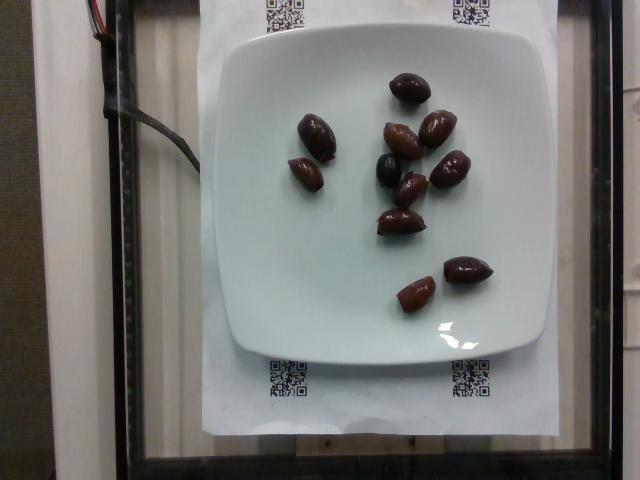


--- MODEL ANALİZİ ---

Yemek Analizi:
- olives (41.0g): 47.0 kcal

Toplam Tahmini Kalori: 47.0 kcal


In [5]:
!pip install -q -U torch torchvision transformers peft bitsandbytes accelerate qwen-vl-utils

import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import PeftModel
from PIL import Image
from IPython.display import display

base_model_id = "Qwen/Qwen2-VL-7B-Instruct"
adapter_path = "/content/drive/MyDrive/Qwen2-VL-Calorie-Model-Final/checkpoint-400"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()

processor = AutoProcessor.from_pretrained(
    base_model_id,
    min_pixels=256*28*28,
    max_pixels=1280*28*28
)

print("Model hazır.")

def analyze_food(image_path: str):
    image = Image.open(image_path)

    if image.mode != "RGB":
        image = image.convert("RGB")

    print("Yüklenen Fotoğraf:")
    display(image)

    system_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
    user_prompt = (
        "<|im_start|>user\n"
        "<|vision_start|><|image_pad|><|vision_end|>"
        "Fotoğraftaki yiyecekleri listele ve her birinin yaklaşık kalorisini tahmin et."
        "<|im_end|>\n"
    )
    assistant_prompt = "<|im_start|>assistant\n"

    full_prompt = system_prompt + user_prompt + assistant_prompt

    inputs = processor(
        text=[full_prompt],
        images=[image],
        padding=True,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]

image_path = "/content/drive/MyDrive/test_food.jpg"

result = analyze_food(image_path)

print("\n--- MODEL ANALİZİ ---\n")
print(result)
